# FraudNet — Exploration des transactions légitimes
Analyse du fichier `data/generated/transactions.parquet` généré par `transaction_engine.py`.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
PALETTE = sns.color_palette("tab10")

df = pd.read_parquet("../data/generated/transactions.parquet")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.date

print(f"Transactions : {len(df):,}")
print(f"Période      : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Comptes      : {df['account_id'].nunique():,}")
df.head(3)

Transactions : 228,556
Période      : 2026-02-02 → 2026-05-03
Comptes      : 1,000


,transaction_id,account_id,archetype,timestamp,montant,commercant,categorie,device,ville_tx,est_weekend,heure,jour_semaine,is_fraud,fraud_type,date
0,af413f3d-7687-4dd7-8bb0-f5f60f939155,8b177bca-24ea-4476-9b2c-26a06b8bb554,jeune_actif,2026-02-02 07:01:53,33.81,Expedia,voyage,mobile,Quebec,False,7,0,False,None,2026-02-02
1,739e12bc-fda3-42b0-ae77-812274d784bd,6b76f456-22c8-425c-b6f8-906c60c551f9,jeune_actif,2026-02-02 07:02:24,72.29,Booking.com,voyage,mobile,Montreal,False,7,0,False,None,2026-02-02
2,817e6713-7b4d-49b4-bc48-828d93357e72,71d31650-4aa5-47ed-a674-a5bdc0940ed8,jeune_actif,2026-02-02 07:02:47,85.05,Staples,fournisseurs,mobile,Montreal,False,7,0,False,None,2026-02-02


## 1. Volume quotidien de transactions

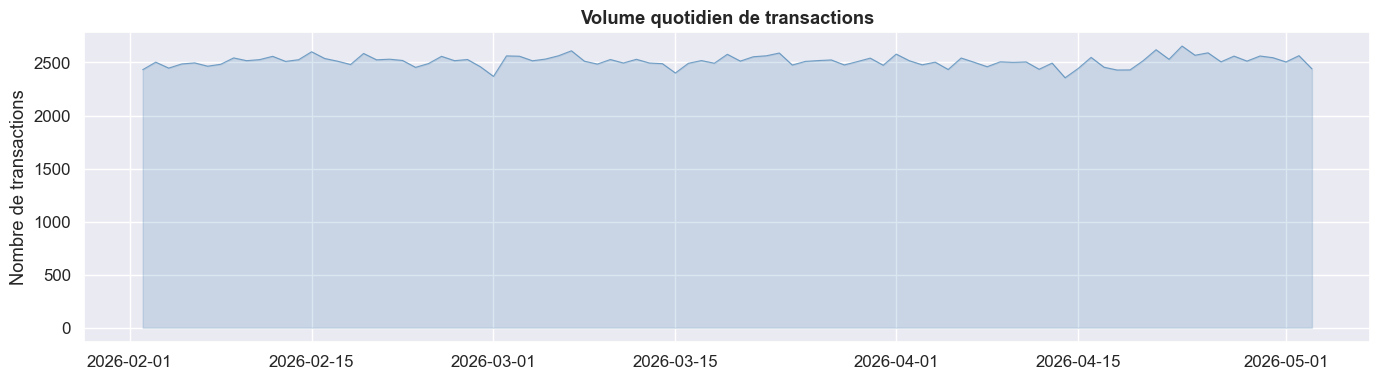

In [2]:
daily = df.groupby("date").size().reset_index(name="n")
daily["date"] = pd.to_datetime(daily["date"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily["date"], daily["n"], color="steelblue", linewidth=0.8, alpha=0.7)
ax.fill_between(daily["date"], daily["n"], alpha=0.2, color="steelblue")
ax.set_title("Volume quotidien de transactions", fontweight="bold")
ax.set_ylabel("Nombre de transactions")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 2. Distribution des montants par archétype

/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_30793/2792516969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


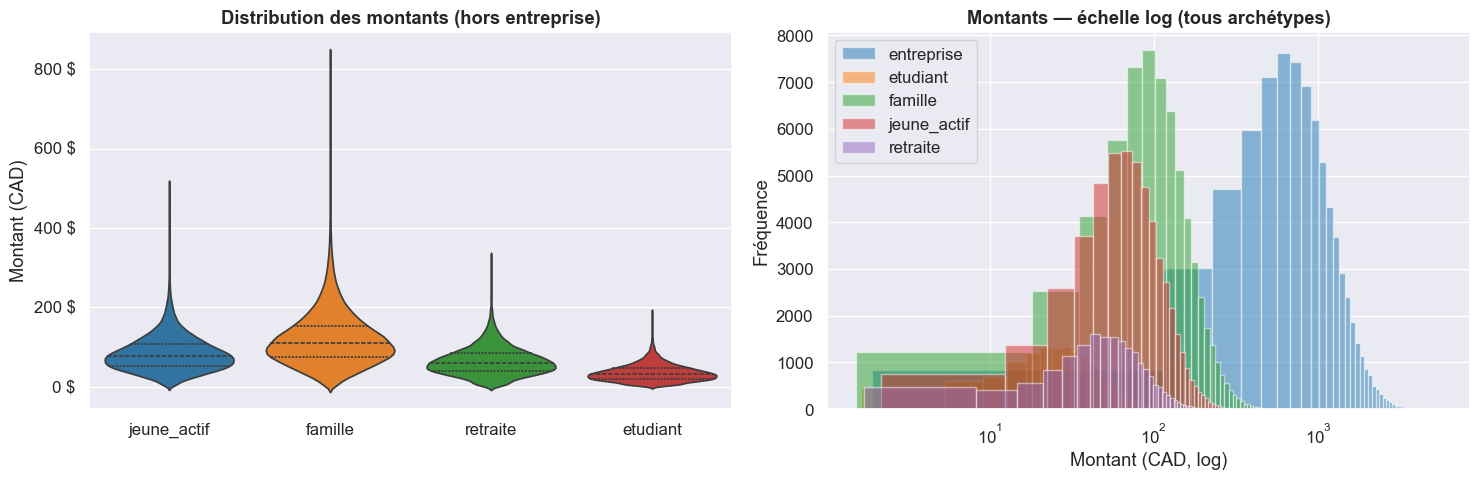

,mean,50%,min,max
archetype,,,,
entreprise,911.85,814.68,1.93,5627.28
etudiant,35.55,32.11,1.64,188.26
famille,120.36,109.29,1.53,835.77
jeune_actif,83.69,77.10,2.18,509.27
retraite,65.11,60.02,1.72,327.34


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Violon (hors entreprise pour l'échelle)
sns.violinplot(
    data=df[df["archetype"] != "entreprise"],
    x="archetype", y="montant",
    palette="tab10", inner="quartile", ax=axes[0]
)
axes[0].set_title("Distribution des montants (hors entreprise)", fontweight="bold")
axes[0].set_ylabel("Montant (CAD)")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} $"))

# Histogramme log
for i, (arch, grp) in enumerate(df.groupby("archetype")):
    axes[1].hist(grp["montant"], bins=50, alpha=0.5, label=arch, color=PALETTE[i])
axes[1].set_xscale("log")
axes[1].set_title("Montants — échelle log (tous archétypes)", fontweight="bold")
axes[1].set_xlabel("Montant (CAD, log)")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.tight_layout()
plt.show()

df.groupby("archetype")["montant"].describe()[["mean","50%","min","max"]].round(2)

## 3. Patterns horaires — à quelle heure on dépense ?

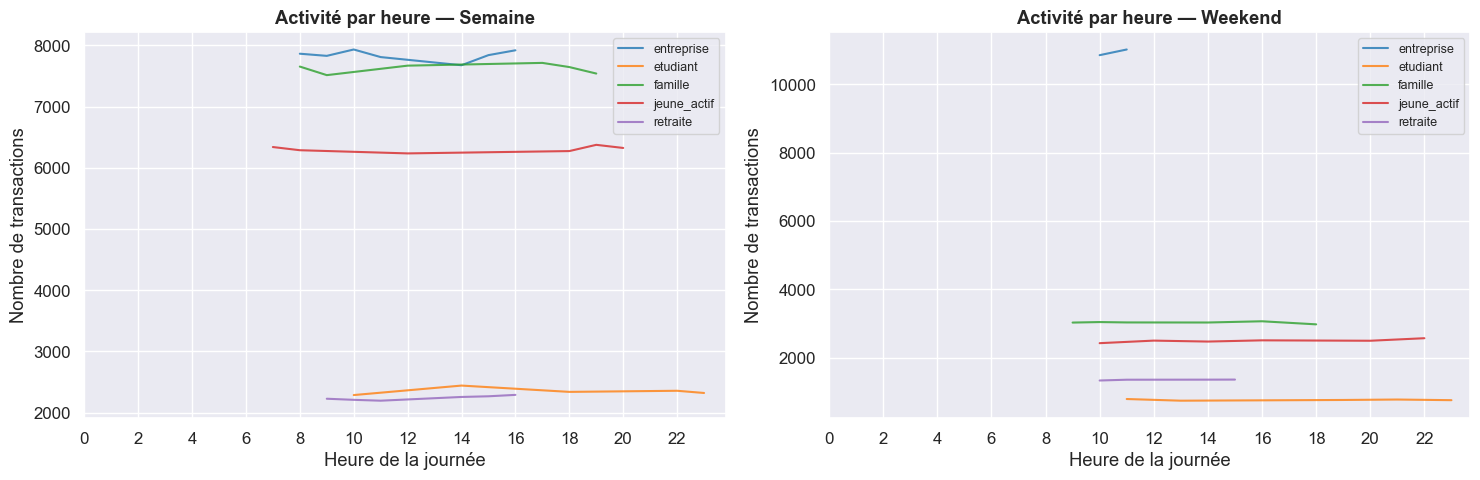

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (label, mask) in enumerate([("Semaine", ~df["est_weekend"]), ("Weekend", df["est_weekend"])]):
    data = df[mask]
    for i, (arch, grp) in enumerate(data.groupby("archetype")):
        counts = grp["heure"].value_counts().sort_index()
        axes[idx].plot(counts.index, counts.values, label=arch, color=PALETTE[i], alpha=0.8)
    axes[idx].set_title(f"Activité par heure — {label}", fontweight="bold")
    axes[idx].set_xlabel("Heure de la journée")
    axes[idx].set_ylabel("Nombre de transactions")
    axes[idx].set_xticks(range(0, 24, 2))
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Heatmap jour de semaine × heure

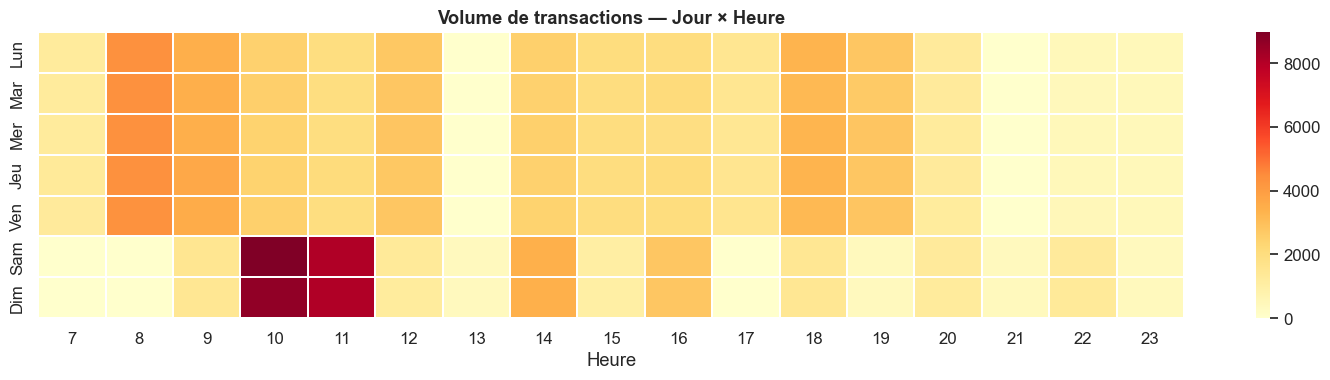

In [5]:
pivot = df.groupby(["jour_semaine", "heure"]).size().unstack(fill_value=0)
jours_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
pivot.index = jours_labels

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.2, ax=ax)
ax.set_title("Volume de transactions — Jour × Heure", fontweight="bold")
ax.set_xlabel("Heure")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Top commerçants et catégories

/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_30793/3896047589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_comm.values, y=top_comm.index, palette="Blues_r", ax=axes[0])


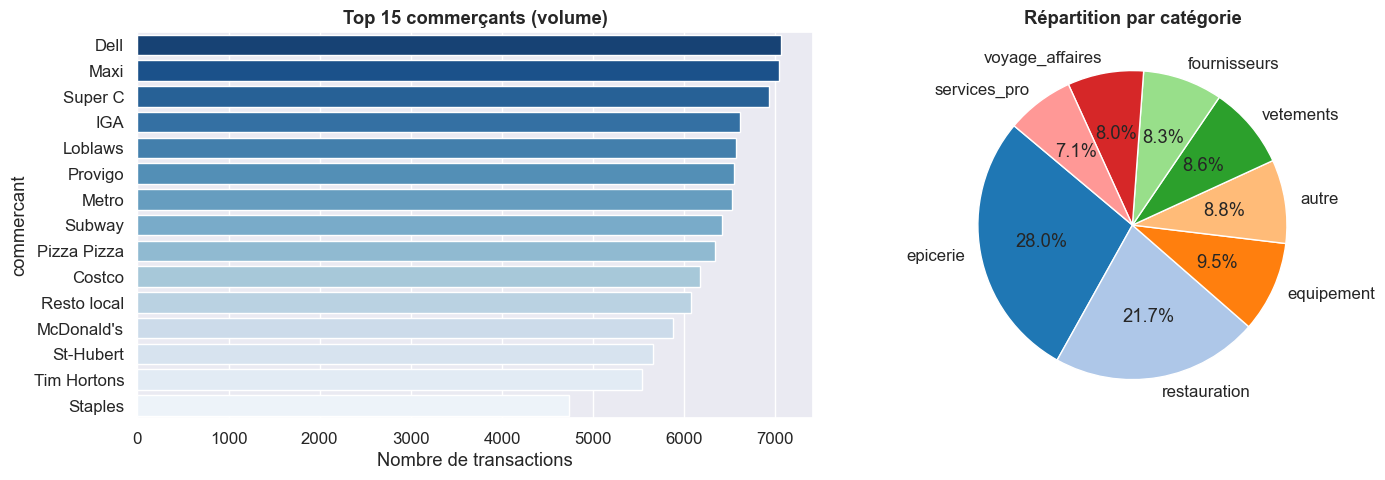

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 15 commerçants par volume
top_comm = df["commercant"].value_counts().head(15)
sns.barplot(x=top_comm.values, y=top_comm.index, palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 15 commerçants (volume)", fontweight="bold")
axes[0].set_xlabel("Nombre de transactions")

# Catégories
cat_counts = df["categorie"].value_counts()
axes[1].pie(cat_counts.values[:8], labels=cat_counts.index[:8],
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("tab20"),
            wedgeprops=dict(edgecolor="white", linewidth=1))
axes[1].set_title("Répartition par catégorie", fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Cohérence géographique — transactions hors ville

Transactions hors ville d'origine : 11,514 (5.0%)


/var/folders/0r/yccbt2rs1p72w8f7g0zfj8dc0000gn/T/ipykernel_30793/3125328975.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dep_arch.index, y=dep_arch.values, palette="tab10", ax=ax)


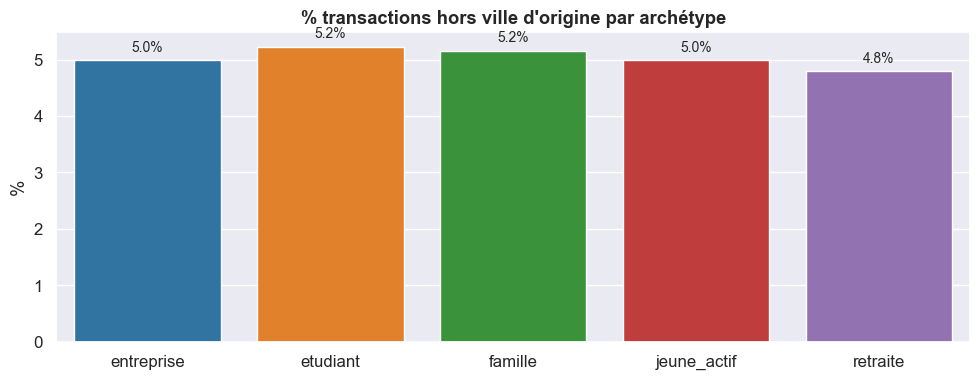

In [7]:
accounts = pd.read_parquet("../data/generated/accounts.parquet")[["account_id", "ville"]]
df_geo = df.merge(accounts, on="account_id")
df_geo["deplacement"] = df_geo["ville_tx"] != df_geo["ville"]

print(f"Transactions hors ville d'origine : {df_geo['deplacement'].sum():,} "
      f"({df_geo['deplacement'].mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
dep_arch = df_geo.groupby("archetype")["deplacement"].mean() * 100
sns.barplot(x=dep_arch.index, y=dep_arch.values, palette="tab10", ax=ax)
ax.set_title("% transactions hors ville d'origine par archétype", fontweight="bold")
ax.set_ylabel("%")
ax.set_xlabel("")
for bar, v in zip(ax.patches, dep_arch.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Vérification de cohérence — le profil est-il respecté ?

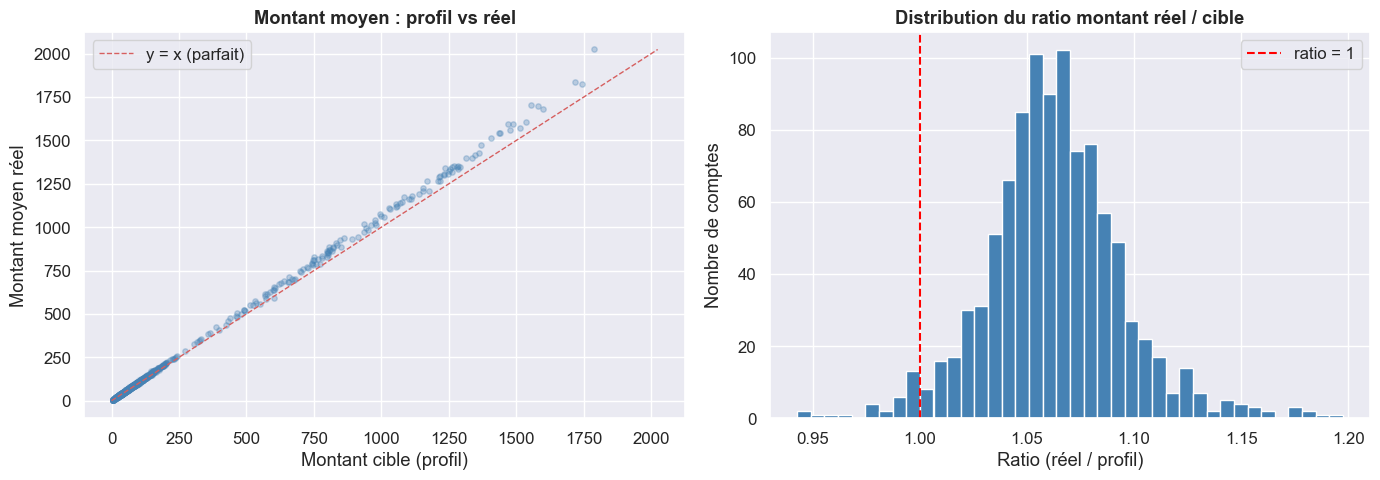

Ratio médian : 1.06  (idéal = ~1.2 à cause de la lognormale)


In [8]:
accounts_full = pd.read_parquet("../data/generated/accounts.parquet")[
    ["account_id", "montant_moyen_transaction", "frequence_hebdo"]
]

# Montant moyen réel vs profil
montant_reel = df.groupby("account_id")["montant"].mean().rename("montant_reel")
compare = accounts_full.join(montant_reel, on="account_id")
compare["ratio"] = compare["montant_reel"] / compare["montant_moyen_transaction"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(compare["montant_moyen_transaction"], compare["montant_reel"],
                alpha=0.3, s=15, color="steelblue")
lim = max(compare["montant_moyen_transaction"].max(), compare["montant_reel"].max())
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1, label="y = x (parfait)")
axes[0].set_title("Montant moyen : profil vs réel", fontweight="bold")
axes[0].set_xlabel("Montant cible (profil)")
axes[0].set_ylabel("Montant moyen réel")
axes[0].legend()

axes[1].hist(compare["ratio"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="ratio = 1")
axes[1].set_title("Distribution du ratio montant réel / cible", fontweight="bold")
axes[1].set_xlabel("Ratio (réel / profil)")
axes[1].set_ylabel("Nombre de comptes")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Ratio médian : {compare['ratio'].median():.2f}  (idéal = ~1.2 à cause de la lognormale)")

## 8. Résumé

In [9]:
print("=" * 55)
print("RÉSUMÉ DU FLUX DE TRANSACTIONS LÉGITIMES")
print("=" * 55)
print(f"  Transactions totales      : {len(df):,}")
print(f"  Comptes actifs            : {df['account_id'].nunique():,}")
print(f"  Période simulée           : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"  Montant médian            : {df['montant'].median():.2f} $")
print(f"  Montant total simulé      : {df['montant'].sum():,.0f} $")
print(f"  Transactions weekend      : {df['est_weekend'].mean()*100:.1f}%")
print(f"  Déplacements géo          : {(df['ville_tx'] != df.merge(accounts, on='account_id')['ville']).mean()*100:.1f}%")
print(f"  Commerçants uniques       : {df['commercant'].nunique()}")
print(f"  is_fraud = True           : {df['is_fraud'].sum()} (0% — normal, injecteur à venir)")
print("=" * 55)
print("\nProchaine étape : fraud_injector.py")
print("→ Injecter des scénarios frauduleux dans ce flux")

RÉSUMÉ DU FLUX DE TRANSACTIONS LÉGITIMES
  Transactions totales      : 228,556
  Comptes actifs            : 1,000
  Période simulée           : 2026-02-02 → 2026-05-03
  Montant médian            : 119.85 $
  Montant total simulé      : 83,898,162 $
  Transactions weekend      : 28.4%
  Déplacements géo          : 5.0%
  Commerçants uniques       : 68
  is_fraud = True           : 0 (0% — normal, injecteur à venir)

Prochaine étape : fraud_injector.py
→ Injecter des scénarios frauduleux dans ce flux
